# Fleet Model Runner

Run the fleet model from the config file and load the saved result tables.

# Konfigurierte Policy-Szenarien und BEV-Zielpfade

Die Namen und Prozentwerte werden direkt aus `fleet_model_config.json` gelesen. Neue Einträge unter `bev_target_scenarios` erscheinen automatisch in den Modellresultaten und Diagrammen.

In [7]:
import importlib.util
from pathlib import Path
import pandas as pd

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

spec = importlib.util.spec_from_file_location("fleet_model_with_policies", script_path)
fleet_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fleet_model)
model_config = fleet_model.load_config(config_path)

fixed_scenarios = model_config["policies"]["scenarios"]
bev_target_scenarios = model_config["policies"].get("bev_target_scenarios", {})
all_scenarios = fleet_model.policy_scenario_names(model_config)

scenario_overview = pd.DataFrame({
    "Szenario": all_scenarios,
    "Typ": [
        "BEV-Zielpfad" if name in bev_target_scenarios else "Feste Policy"
        for name in all_scenarios
    ],
})
display(scenario_overview)

start_year = int(model_config["years"]["start_year"])
end_year = int(model_config["years"]["end_year"])
bev_target_overview = pd.DataFrame(
    [
        {
            "Szenario": scenario_name,
            "Jahr": year,
            "BEV-Zielanteil [%]": 100 * fleet_model.bev_target_share(
                year, scenario_name, model_config
            ),
        }
        for scenario_name in bev_target_scenarios
        for year in range(start_year, end_year + 1)
    ]
)

display(
    bev_target_overview.pivot(
        index="Jahr", columns="Szenario", values="BEV-Zielanteil [%]"
    ).round(3)
)

,Szenario,Typ
0,diesel_fahrverbot,Feste Policy
1,abwrackpraemie,Feste Policy
2,verbrenneraus_2035,BEV-Zielpfad
3,verbrenneraus_light,BEV-Zielpfad
4,baseline_ev_growth,BEV-Zielpfad
5,stronger_ev_growth,BEV-Zielpfad


Szenario,baseline_ev_growth,stronger_ev_growth,verbrenneraus_2035,verbrenneraus_light
Jahr,,,,
2025,19.159,19.159,19.159,19.159
2026,21.654,22.277,27.243,26.243
2027,24.148,25.396,35.327,33.327
2028,26.643,28.514,43.412,40.412
2029,29.137,31.632,51.496,47.496
2030,31.632,34.750,59.580,54.580
2031,34.126,37.868,67.664,61.664
2032,36.621,40.986,75.748,68.748
2033,39.115,44.104,83.832,75.832


In [8]:
from pathlib import Path
import subprocess
import sys

model_dir = Path(r"C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model")
script_path = model_dir / "fleet_model_with_policies.py"
config_path = model_dir / "fleet_model_config.json"

command = [sys.executable, str(script_path), "--config", str(config_path)]
print(" ".join(command))
subprocess.run(command, check=True)

c:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\.venv\Scripts\python.exe C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_with_policies.py --config C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\fleet_model_config.json


CompletedProcess(args=['c:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\.venv\\Scripts\\python.exe', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_with_policies.py', '--config', 'C:\\Users\\annic\\OneDrive\\Dokumente\\Master Technischer Umweltschutz\\Master Thesis\\Emission_Trajectory_Thesis\\Fleet Model\\fleet_model_config.json'], returncode=0)

In [9]:
import pandas as pd

results_dir = model_dir / "Results"

result_files = {
    path.stem: path
    for path in results_dir.glob("*.csv")
}

results = {
    name: pd.read_csv(path, sep=";")
    for name, path in result_files.items()
}

results.keys()

dict_keys(['emissions_by_phase', 'emissions_summary_by_year_phase', 'emissions_summary_by_year_total', 'emissions_summary_total_by_scenario', 'emission_parameters_long_prepared', 'fleet_size_final_stock_all', 'fleet_size_new_vehicles_all', 'fleet_size_summary_all', 'fleet_size_target_paths_all', 'fleet_total', 'hazard_pooled', 'policy_exits_all', 'policy_final_stock_all', 'policy_final_stock_all_prepared_for_emissions', 'policy_missing_vehicles_all', 'policy_new_vehicles_all', 'policy_reentries_all', 'policy_stock_before_new_vehicles_all', 'policy_summary_all', 'prepared_exits_lca', 'prepared_final_stock_lca', 'prepared_new_vehicles_lca', 'reentry_pooled', 'reentry_yearly'])

In [10]:
# Main result dataframes for evaluation
policy_summary_all = results["policy_summary_all"]
policy_final_stock_all = results["policy_final_stock_all"]
policy_exits_all = results["policy_exits_all"]
policy_reentries_all = results["policy_reentries_all"]
policy_new_vehicles_all = results["policy_new_vehicles_all"]

policy_summary_all.head()

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.939100e+07,4.602304e+07,3.367964e+06,4.939100e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.965722e+07,4.618704e+07,3.470183e+06,4.965722e+07,0.000000e+00
3,diesel_fahrverbot,2028,4.992487e+07,4.635978e+07,3.565083e+06,4.992487e+07,0.000000e+00
4,diesel_fahrverbot,2029,5.019396e+07,4.654385e+07,3.650111e+06,5.019396e+07,7.450581e-09


In [11]:
policy_summary_all

,Szenario,Jahr,zielbestand,bestand_vor_neuen_fahrzeugen,fehlende_fahrzeuge,finaler_bestand,abweichung_final_vs_ziel
0,diesel_fahrverbot,2025,4.912622e+07,4.912620e+07,1.600000e+01,4.912620e+07,-1.600000e+01
1,diesel_fahrverbot,2026,4.939100e+07,4.602304e+07,3.367964e+06,4.939100e+07,-7.450581e-09
2,diesel_fahrverbot,2027,4.965722e+07,4.618704e+07,3.470183e+06,4.965722e+07,0.000000e+00
3,diesel_fahrverbot,2028,4.992487e+07,4.635978e+07,3.565083e+06,4.992487e+07,0.000000e+00
4,diesel_fahrverbot,2029,5.019396e+07,4.654385e+07,3.650111e+06,5.019396e+07,7.450581e-09
...,...,...,...,...,...,...,...
157,stronger_ev_growth,2047,5.529337e+07,5.093349e+07,4.359876e+06,5.529337e+07,0.000000e+00
158,stronger_ev_growth,2048,5.559139e+07,5.121518e+07,4.376211e+06,5.559139e+07,0.000000e+00
159,stronger_ev_growth,2049,5.589103e+07,5.148835e+07,4.402675e+06,5.589103e+07,-7.450581e-09
160,stronger_ev_growth,2050,5.619228e+07,5.178020e+07,4.412077e+06,5.619228e+07,0.000000e+00


# Plot

Gefundene Szenarien:
['abwrackpraemie', 'baseline_ev_growth', 'diesel_fahrverbot', 'stronger_ev_growth', 'verbrenneraus_2035', 'verbrenneraus_light']

Gefundene Antriebsarten:
['Benzin', 'Diesel', 'Elektro (BEV)', 'Hybrid']


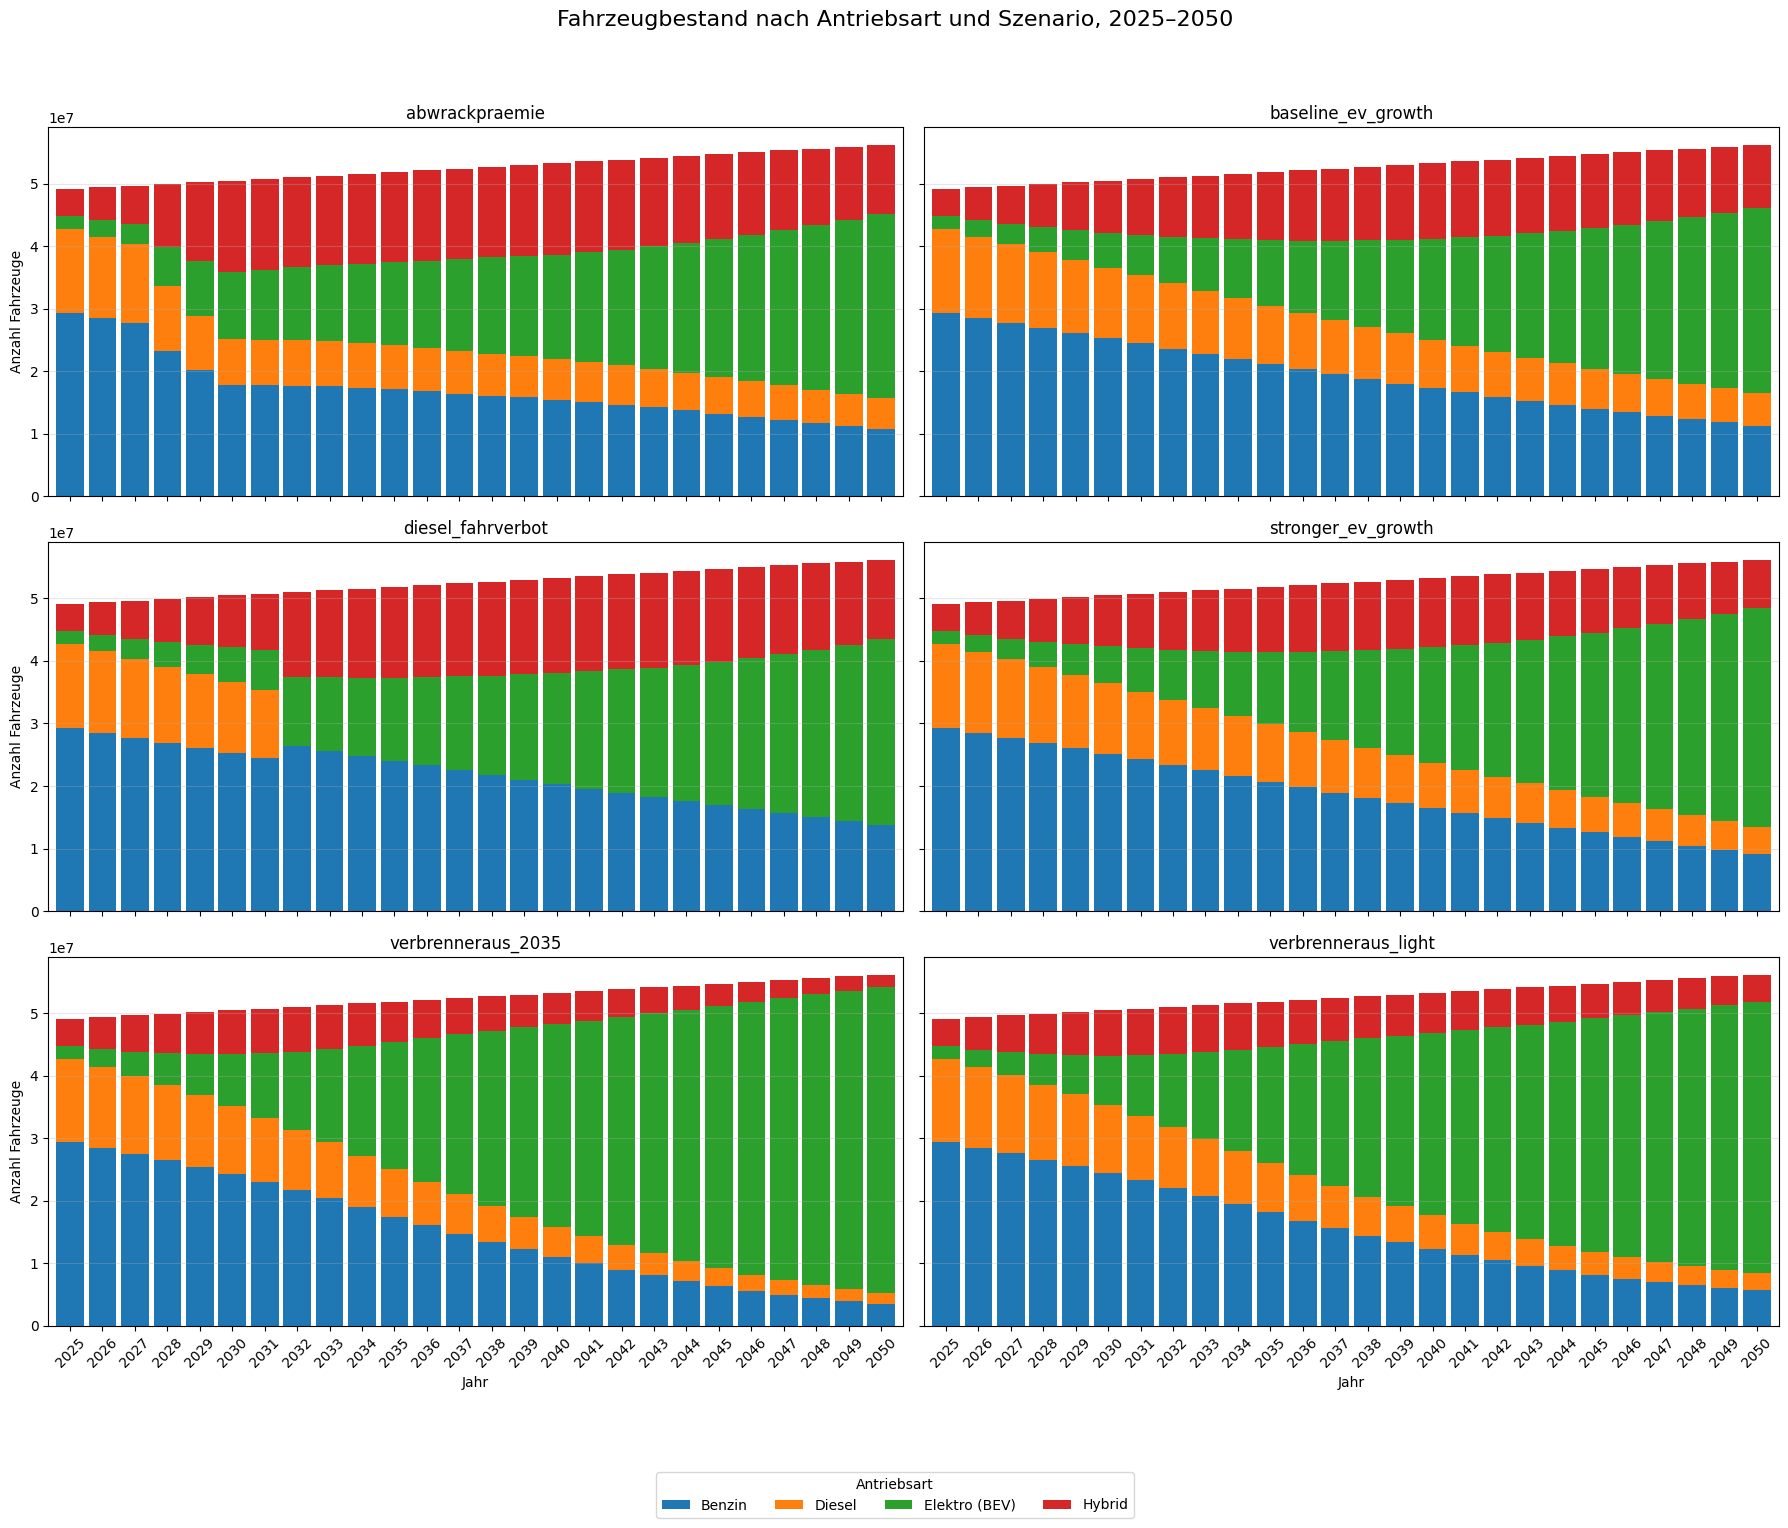

Grafik gespeichert unter:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Fleet Model\Results\policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png


In [12]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Frisch berechnete Ergebnisdaten verwenden
# ------------------------------------------------------------

df = policy_final_stock_all.copy()

# ------------------------------------------------------------
# 2. Datentypen bereinigen
# ------------------------------------------------------------

df["Jahr"] = df["Jahr"].astype(int)
df["finaler_bestand"] = pd.to_numeric(df["finaler_bestand"], errors="coerce")

# ------------------------------------------------------------
# 3. Nur Jahre 2025 bis 2050 verwenden
# ------------------------------------------------------------

df = df[(df["Jahr"] >= 2025) & (df["Jahr"] <= 2050)]

# ------------------------------------------------------------
# 4. Fahrzeugbestand pro Szenario, Jahr und Antriebsart summieren
# ------------------------------------------------------------

agg = (
    df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)["finaler_bestand"]
    .sum()
)

# ------------------------------------------------------------
# 5. Szenarien und Antriebsarten bestimmen
# ------------------------------------------------------------

szenarien = sorted(agg["Szenario"].unique())
antriebsarten = sorted(agg["Antriebsart"].unique())

print("Gefundene Szenarien:")
print(szenarien)

print("\nGefundene Antriebsarten:")
print(antriebsarten)

# ------------------------------------------------------------
# 6. Dynamisches Plot-Raster für alle Szenarien erstellen
# ------------------------------------------------------------

ncols = 2
nrows = math.ceil(len(szenarien) / ncols)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 5 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False
)

axes = axes.flatten()

for ax, szenario in zip(axes, szenarien):
    
    data_szenario = agg[agg["Szenario"] == szenario]

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Antriebsarten
    # Werte = Fahrzeugbestand
    pivot = (
        data_szenario
        .pivot_table(
            index="Jahr",
            columns="Antriebsart",
            values="finaler_bestand",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(range(2025, 2051), fill_value=0)
    )

    # Sicherstellen, dass in jedem Subplot alle Antriebsarten vorkommen
    pivot = pivot.reindex(columns=antriebsarten, fill_value=0)

    # Gestapeltes Balkendiagramm
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.85
    )

    ax.set_title(szenario)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Anzahl Fahrzeuge")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

    # Einzelne Legende entfernen, da später gemeinsame Legende kommt
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Nicht benötigte Subplots ausblenden
for i in range(len(szenarien), len(axes)):
    axes[i].set_visible(False)

# ------------------------------------------------------------
# 7. Gemeinsame Legende erstellen
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Antriebsart",
    loc="lower center",
    ncol=len(antriebsarten),
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Fahrzeugbestand nach Antriebsart und Szenario, 2025–2050",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# ------------------------------------------------------------
# 8. Grafik speichern
# ------------------------------------------------------------

output_path = results_dir / "policy_fahrzeugbestand_szenarien_antriebsarten_2025_2050.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Grafik gespeichert unter:\n{output_path}")